# Plotting Paolo's Data

In [37]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import mpld3
%matplotlib inline
# import seaborn as sns
# sns.set()

<details>
    <summary>Paolo's request</summary>
I need your advice on working with the attached .csv file, which lists nominal X-Y positions in column C and measured X-Y positions in column H for circles numbered from 5 (Rows 2-3) all the way up to 47,264 (Rows 141,779-141,780).  My goal is to plot all 47,264 measured points on an X-Y plot, using two distinct colors: green for points marked as “Pass” and red for those marked as “Fail”  in column I, disregarding rows with D (diameter) values (Row 4, 7, 10, 13,..).  This would really help me visually assess the results for a large number of data points.
</details>

## The data file

In [38]:
DATA_FILE_PATH = '../DATA/data_ai-2.csv'

## Original data

In [39]:
with open(DATA_FILE_PATH, encoding="utf-8") as data_in:
    for (i, raw_line) in enumerate(data_in):
        line = raw_line.rstrip()
        print(line)
        if i == 10:
            break

﻿,,Nom.,UpperTol.,,LowerTol.,,Meas.,Insp.
5.Circle,X,0,0.0008,0.0008,-0.0008,-0.0008,0,Pass
5.Circle,Y,0,0.0008,0.0008,-0.0008,-0.0008,0,Pass
5.Circle,D,0.015,0.0008,0.0158,-0.0008,0.0142,0.01371,Fail
6.Circle,X,0,0.0008,0.0008,-0.0008,-0.0008,0,Pass
6.Circle,Y,0,0.0008,0.0008,-0.0008,-0.0008,0,Pass
6.Circle,D,0.015,0.0008,0.0158,-0.0008,0.0142,0.01371,Fail
7.Circle,X,0.0414,0.0008,0.0422,-0.0008,0.0406,0.04155,Pass
7.Circle,Y,0,0.0008,0.0008,-0.0008,-0.0008,0.00001,Pass
7.Circle,D,0.015,0.0008,0.0158,-0.0008,0.0142,0.0135,Fail
8.Circle,X,0.0828,0.0008,0.0836,-0.0008,0.082,0.08277,Pass


## Creating the first dataframe

In [40]:
circle_data = pd.read_csv(DATA_FILE_PATH, usecols=[0,1,7,8], dtype={'Insp.': 'category'}, header=0,
                         names = ['Circle', 'Axis', 'Position', 'Inspection'])
circle_data

,Circle,Axis,Position,Inspection
0,5.Circle,X,0.00000,Pass
1,5.Circle,Y,0.00000,Pass
2,5.Circle,D,0.01371,Fail
3,6.Circle,X,0.00000,Pass
4,6.Circle,Y,0.00000,Pass
...,...,...,...,...
141775,47263.Circle,Y,3.66511,Fail
141776,47263.Circle,D,0.01471,Pass
141777,47264.Circle,X,10.95229,Fail
141778,47264.Circle,Y,3.66504,Fail


## Getting the X and y values
We use a slice to grab every third row, starting with the first row for X values and the second row for Y values. We rename the 'position' and 'fail' columns to be unique when we merge with the Y values.

We do the same thing for the y values, starting with the second row.

In [41]:
x_values = circle_data.loc[::3, ['Circle', 'Position', 'Inspection']]
x_values.columns = ['circle', 'x-position', 'x-fail']
x_values

,circle,x-position,x-fail
0,5.Circle,0.00000,Pass
3,6.Circle,0.00000,Pass
6,7.Circle,0.04155,Pass
9,8.Circle,0.08277,Pass
12,9.Circle,0.12428,Pass
...,...,...,...
141765,47260.Circle,10.78667,Fail
141768,47261.Circle,10.82823,Fail
141771,47262.Circle,10.86950,Fail
141774,47263.Circle,10.91103,Fail


In [42]:
y_values = circle_data.loc[1::3, ['Circle', 'Position', 'Inspection']]
y_values.columns = ['circle', 'y-position', 'y-fail']
y_values

,circle,y-position,y-fail
1,5.Circle,0.00000,Pass
4,6.Circle,0.00000,Pass
7,7.Circle,0.00001,Pass
10,8.Circle,0.00007,Pass
13,9.Circle,0.00006,Pass
...,...,...,...
141766,47260.Circle,3.66509,Fail
141769,47261.Circle,3.66508,Fail
141772,47262.Circle,3.66506,Fail
141775,47263.Circle,3.66511,Fail


## Merging the X values and Y values into one dataframe

In [43]:
all_values = pd.merge(x_values, y_values)
all_values[:100]

,circle,x-position,x-fail,y-position,y-fail
0,5.Circle,0.00000,Pass,0.00000,Pass
1,6.Circle,0.00000,Pass,0.00000,Pass
2,7.Circle,0.04155,Pass,0.00001,Pass
3,8.Circle,0.08277,Pass,0.00007,Pass
4,9.Circle,0.12428,Pass,0.00006,Pass
...,...,...,...,...,...
95,100.Circle,3.89255,Fail,0.00013,Pass
96,101.Circle,3.93378,Pass,0.00021,Pass
97,102.Circle,3.97520,Pass,0.00016,Pass
98,103.Circle,4.01650,Pass,0.00032,Pass


## Rows where both X and Y passed

In [44]:
all_passing_values = all_values[(all_values['x-fail'] == 'Pass') & (all_values['y-fail'] == 'Pass')]
all_passing_values[:100]

,circle,x-position,x-fail,y-position,y-fail
0,5.Circle,0.00000,Pass,0.00000,Pass
1,6.Circle,0.00000,Pass,0.00000,Pass
2,7.Circle,0.04155,Pass,0.00001,Pass
3,8.Circle,0.08277,Pass,0.00007,Pass
4,9.Circle,0.12428,Pass,0.00006,Pass
...,...,...,...,...,...
269,274.Circle,0.10352,Pass,0.02084,Pass
270,275.Circle,0.14505,Pass,0.02084,Pass
271,276.Circle,0.18632,Pass,0.02082,Pass
272,277.Circle,0.22781,Pass,0.02079,Pass


In [45]:
len(all_passing_values)

9966

## Rows where either X or Y failed 

In [46]:
all_failing_values = all_values[(all_values['x-fail'] == 'Fail') | (all_values['y-fail'] == 'Fail')]
all_failing_values[:100]

,circle,x-position,x-fail,y-position,y-fail
74,79.Circle,3.02303,Fail,0.00013,Pass
80,85.Circle,3.27142,Fail,0.00008,Pass
85,90.Circle,3.47846,Fail,0.00023,Pass
87,92.Circle,3.56125,Fail,0.00014,Pass
90,95.Circle,3.68548,Fail,0.00011,Pass
...,...,...,...,...,...
188,193.Circle,7.74360,Fail,0.00006,Pass
189,194.Circle,7.78515,Fail,0.00004,Pass
190,195.Circle,7.82665,Fail,0.00003,Pass
191,196.Circle,7.86787,Fail,0.00000,Pass


In [47]:
len(all_failing_values)

37294

## Getting min and max values
We want to get min and max values for X and Y data, so we can set the x and y limits of the plot.

In [48]:
x_min = all_values['x-position'].min()
x_max = all_values['x-position'].max()
y_min = all_values['y-position'].min()
y_max = all_values['y-position'].max()
x_min, x_max, y_min, y_max

(np.float64(-0.00021),
 np.float64(10.97357),
 np.float64(-0.00014),
 np.float64(3.66525))

## Plotting the data

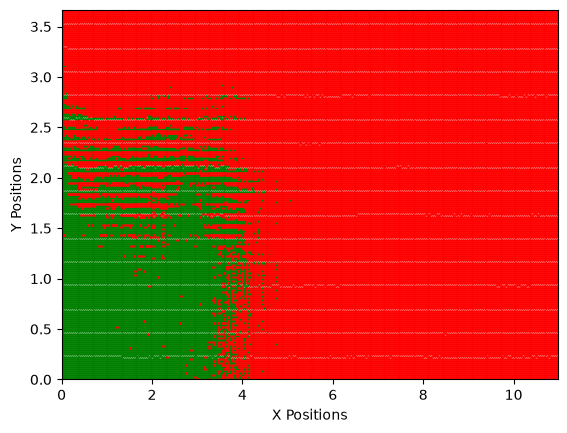

In [49]:
plt.scatter(all_passing_values['x-position'], all_passing_values['y-position'], color='green', s=1)
plt.scatter(all_failing_values['x-position'], all_failing_values['y-position'], color='red', s=1)
plt.xlabel("X Positions")
plt.ylabel("Y Positions")
plt.ylim(y_min, y_max)
plt.xlim(x_min, x_max)
plt.savefig("paolo.png")

## Plotting pass and fail separately
We use subplots to plot pass and fail separately, setting the x scale and y scale to be the same for both plots.

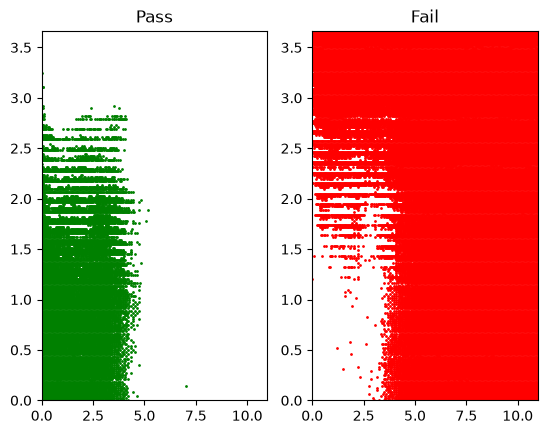

<Figure size 640x480 with 0 Axes>

In [50]:
plt.subplot(1, 2, 1).scatter(all_passing_values['x-position'], all_passing_values['y-position'], color='green', s=1)
plt.ylim(y_min, y_max)
plt.xlim(x_min, x_max)
plt.title("Pass")

plt.subplot(1, 2, 2).scatter(all_failing_values['x-position'], all_failing_values['y-position'], color='red', s=1)
plt.ylim(y_min, y_max)
plt.xlim(x_min, x_max)
plt.title("Fail")
mpld3.save_html(plt.figure(), "paolo.html")

## Hexbin plot

<Axes: xlabel='x-position', ylabel='y-position'>

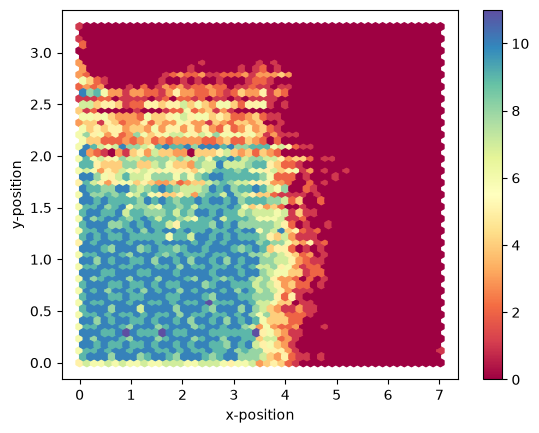

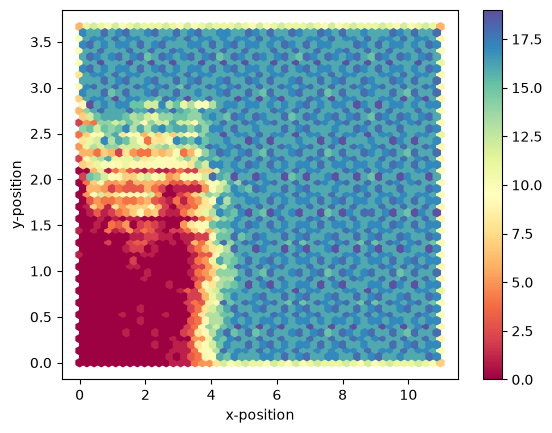

In [51]:
all_passing_values.plot.hexbin('x-position', 'y-position', gridsize=50, cmap='Spectral')
all_failing_values.plot.hexbin('x-position', 'y-position', gridsize=50, cmap='Spectral')

## Getting the percentages which passed and failed

In [52]:
percentage_passed = round(len(all_passing_values) / len(all_values) * 100, 2)
percentage_failed = round(len(all_failing_values) / len(all_values) * 100, 2)
percentage_passed, percentage_failed

(21.09, 78.91)